In [66]:
# === Импорты библиотек ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

import pywt

from sklearn.metrics import mean_squared_error, r2_score

plt.style.use('seaborn-v0_8')

In [72]:
# === Штучьки для графиков ===

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

purple_palette = [
    "#5E2CA5",  # основной фиолетовый
    "#7B4FBF",
    "#9C6ADE",
    "#BFA2DB",
    "#E0D3F5"
]

sns.set_palette(purple_palette)

plt.rcParams.update({
    "figure.figsize": (12,6),
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "axes.titleweight": "bold",
    "axes.edgecolor": "#5E2CA5",
    "grid.color": "#E6E0F8",
    "grid.alpha": 0.6,
    "lines.linewidth": 2.5
})

In [2]:
# === Загрузка данных ===

df = pd.read_csv("retail_sales_mock_data.csv")

df.head()

,Date,SalesAmount,Promotion,HolidayMonth
0,2020-01-01,12248,0,0
1,2020-02-01,13011,0,0
2,2020-03-01,12722,0,0
3,2020-04-01,14030,1,0
4,2020-05-01,7783,0,0


In [ ]:
# === Общая информация о данных ===

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Date          48 non-null     object
 1   SalesAmount   48 non-null     int64 
 2   Promotion     48 non-null     int64 
 3   HolidayMonth  48 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 1.6+ KB


In [4]:
df.describe()

,SalesAmount,Promotion,HolidayMonth
count,48.000000,48.000000,48.000000
mean,11768.541667,0.125000,0.083333
std,2257.544863,0.334219,0.279310
min,7783.000000,0.000000,0.000000
25%,10219.750000,0.000000,0.000000
50%,11851.000000,0.000000,0.000000
75%,13014.000000,0.000000,0.000000
max,17996.000000,1.000000,1.000000


In [5]:
df.isnull().sum()

Date            0
SalesAmount     0
Promotion       0
HolidayMonth    0
dtype: int64

In [7]:
# === Преобразование даты ===

df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values('Date')
df = df.set_index('Date')

df.head()

,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0


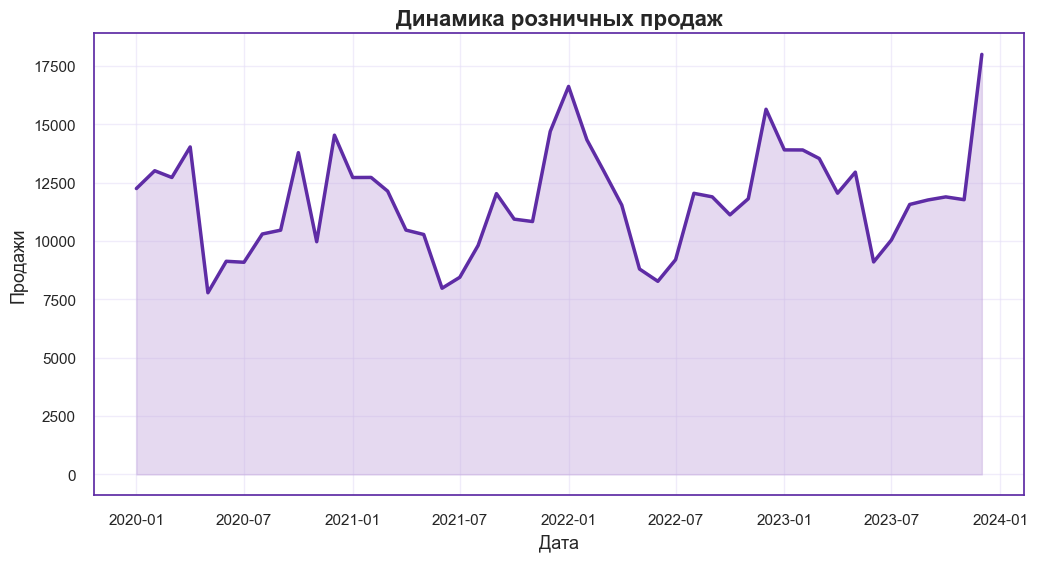

In [ ]:
# === Основной график временного ряда ===

plt.figure()

plt.plot(df.index, df['SalesAmount'], color="#5E2CA5")
plt.fill_between(df.index, df['SalesAmount'], color="#BFA2DB", alpha=0.4)

plt.title("Динамика розничных продаж")
plt.xlabel("Дата")
plt.ylabel("Продажи")

plt.show()

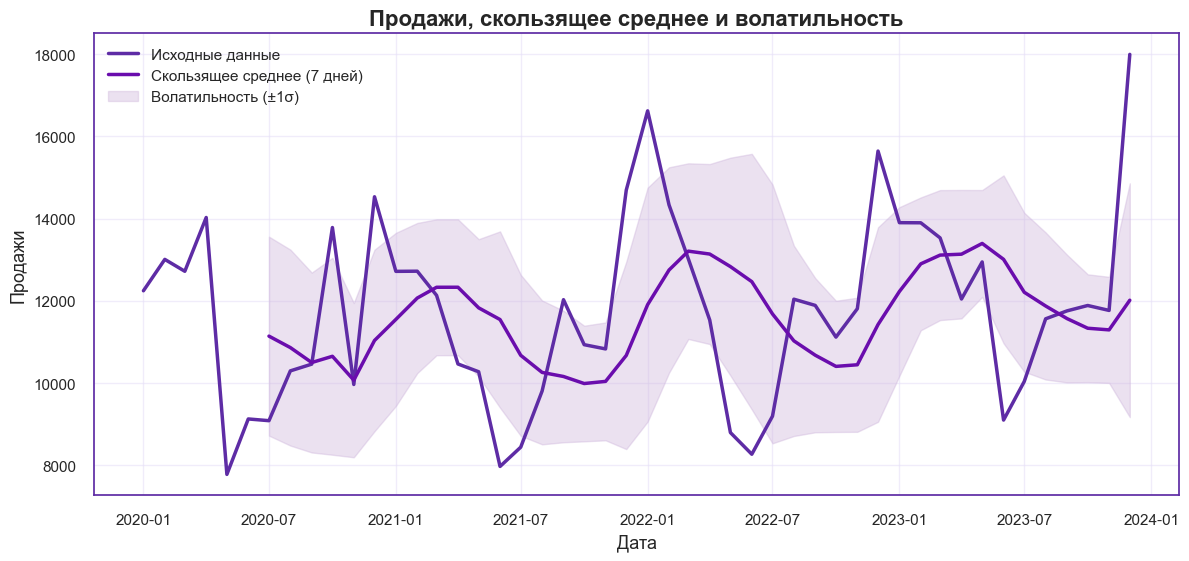

In [24]:
# Скользящее среднее (для визуализации тренда) + волатильность ===

rolling_mean = df['SalesAmount'].rolling(window=7).mean()
rolling_std = df['SalesAmount'].rolling(window=7).std()

upper_band = rolling_mean + rolling_std
lower_band = rolling_mean - rolling_std

plt.figure(figsize=(14,6))

plt.plot(df['SalesAmount'], label='Исходные данные')
plt.plot(rolling_mean, label='Скользящее среднее (7 дней)', color='#6A0DAD')

plt.fill_between(
    df.index,
    lower_band,
    upper_band,
    color='#CDB4DB',
    alpha=0.4,
    label='Волатильность (±1σ)'
)

plt.title("Продажи, скользящее среднее и волатильность")
plt.xlabel("Дата")
plt.ylabel("Продажи")

plt.legend()
plt.show()

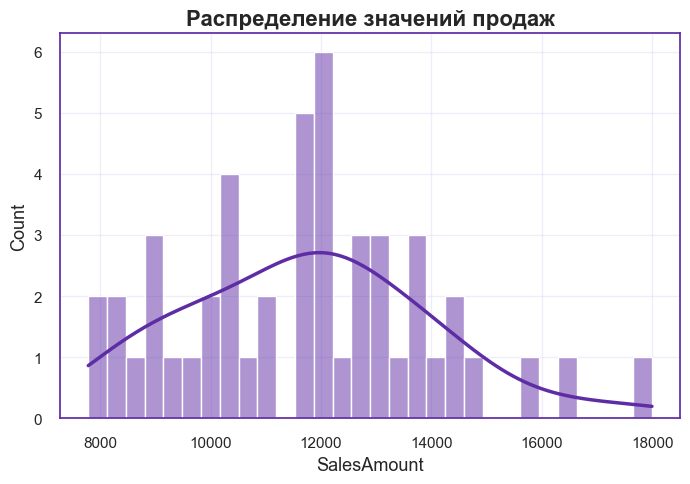

In [20]:
# === Распределение продаж ===

plt.figure(figsize=(8,5))
sns.histplot(df['SalesAmount'], bins=30, kde=True)

plt.title("Распределение значений продаж")

plt.show()

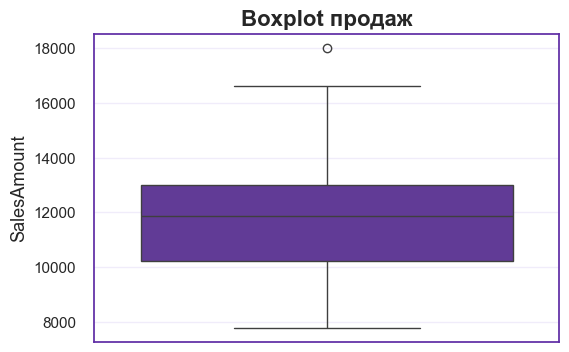

In [ ]:
# === Boxplot (для поиска выбросов) ===

plt.figure(figsize=(6,4))

sns.boxplot(y=df['SalesAmount'])

plt.title("Boxplot продаж")

plt.show()

In [25]:
# === Найдём выброс и обработаем его с помощью межквартильног размаха ===

Q1 = df['SalesAmount'].quantile(0.25)
Q3 = df['SalesAmount'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Нижняя граница:", lower_bound)
print("Верхняя граница:", upper_bound)

outliers = df[(df['SalesAmount'] < lower_bound) | (df['SalesAmount'] > upper_bound)]

outliers

Нижняя граница: 6028.375
Верхняя граница: 17205.375


,SalesAmount,Promotion,HolidayMonth,month
Date,,,,
2023-12-01,17996,0,1,12


In [26]:
df['SalesAmount_clean'] = df['SalesAmount'].clip(lower_bound, upper_bound)

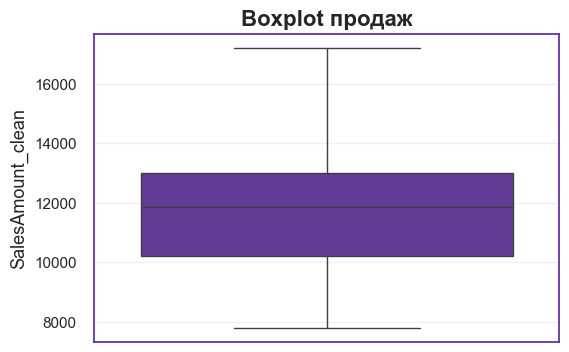

In [30]:
# === Boxplot (проверка, что выброс корректно обработан) ===

plt.figure(figsize=(6,4))

sns.boxplot(y=df['SalesAmount_clean'])

plt.title("Boxplot продаж")

plt.show()

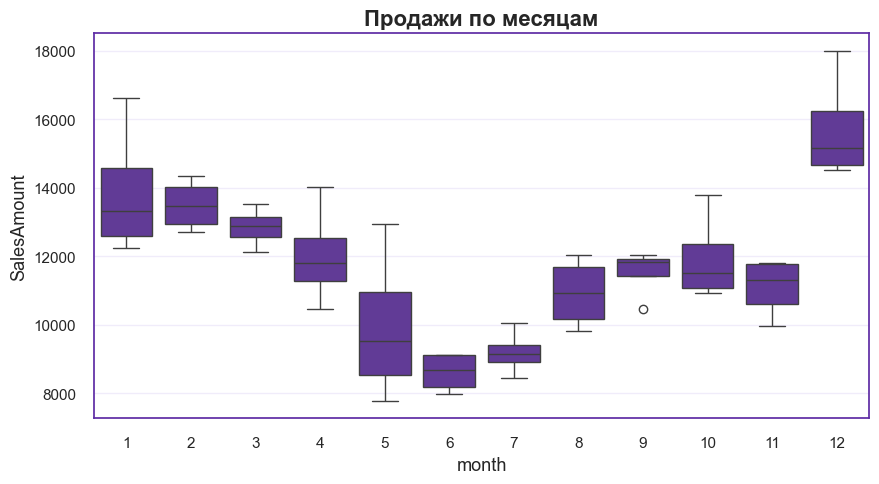

In [33]:
# === Продажи по месяцам (поиск сезонности) ===

df['month'] = df.index.month

plt.figure(figsize=(10,5))
sns.boxplot(x='month', y='SalesAmount', data=df)

plt.title("Продажи по месяцам")

plt.show()

*Краткая аналитическая сводка для блока EDA:*

Предварительный анализ временного ряда (EDA)

На первом этапе был проведён первичный анализ временного ряда розничных продаж. Данные содержат 48 наблюдений, соответствующих ежемесячным продажам за период с 2020 по 2023 год. В наборе данных присутствуют следующие признаки: дата наблюдения, объём продаж (SalesAmount), наличие промоакций (Promotion) и признак праздничного месяца (HolidayMonth). Пропуски в данных отсутствуют, что позволяет использовать временной ряд для дальнейшего анализа без дополнительной обработки.

Согласно описательной статистике, средний объём продаж составляет 11768 единиц, медианное значение — 11851, что свидетельствует о достаточно симметричном распределении значений. Минимальное значение продаж равно 7783, максимальное — 17996. Стандартное отклонение составляет 2257, что указывает на умеренную вариативность продаж.

Анализ графика динамики продаж показывает наличие колебаний объёма продаж во времени. Значения ряда изменяются неравномерно, наблюдаются периоды роста и снижения продаж. В ряде можно заметить повторяющиеся колебания, что может свидетельствовать о наличии сезонных эффектов, характерных для розничной торговли.

Для более наглядного выявления общей тенденции была построена линия скользящего среднего с окном 7 периодов. Она позволяет сгладить краткосрочные колебания и лучше проследить динамику изменения продаж. Дополнительно была визуализирована волатильность временного ряда, рассчитанная как скользящее стандартное отклонение. Анализ данного графика показывает, что уровень вариативности продаж меняется во времени: в некоторые периоды наблюдаются более сильные колебания значений.

Анализ распределения значений продаж показывает, что основная масса наблюдений сосредоточена в диапазоне от 10 000 до 13 000, при этом распределение имеет умеренную асимметрию. Для выявления аномальных значений был построен boxplot, который показал наличие одного выброса.

Для обнаружения выбросов был применён метод межквартильного размаха (IQR). В результате был выявлен один аномальный наблюдаемый уровень продаж — 17996, соответствующий дате 01.12.2023. Данное значение значительно превышает верхнюю границу межквартильного диапазона и может быть связано с аномальным всплеском продаж, например, из-за сезонных факторов или праздничного периода.

Выброс был обработан методом ограничения значений (clipping), при котором значения, выходящие за допустимые границы, заменяются на граничные значения межквартильного диапазона. После обработки выбросов повторный анализ boxplot показал отсутствие аномальных значений, что свидетельствует о корректности выполненной обработки.

Таким образом, проведённый предварительный анализ показал, что временной ряд обладает характерными для розничных продаж свойствами: наличием колебаний, возможных сезонных эффектов и умеренной вариативностью значений. Подготовленные данные могут быть использованы для дальнейшего анализа временного ряда и построения моделей прогнозирования.

---

*1.2 Декомпозиция временного ряда*

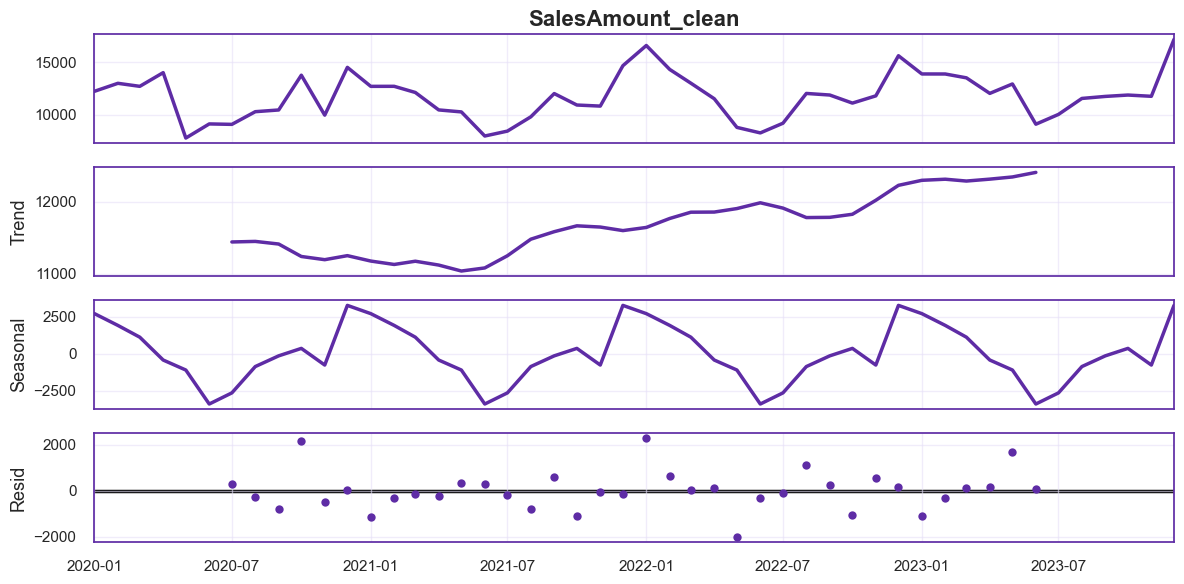

In [73]:
# === Классическая декомпозиция временного ряда ===

# Аддитивная модель

decomposition_add = seasonal_decompose(
    df['SalesAmount_clean'],
    model='additive',
    period=12
)

decomposition_add.plot()
plt.show()

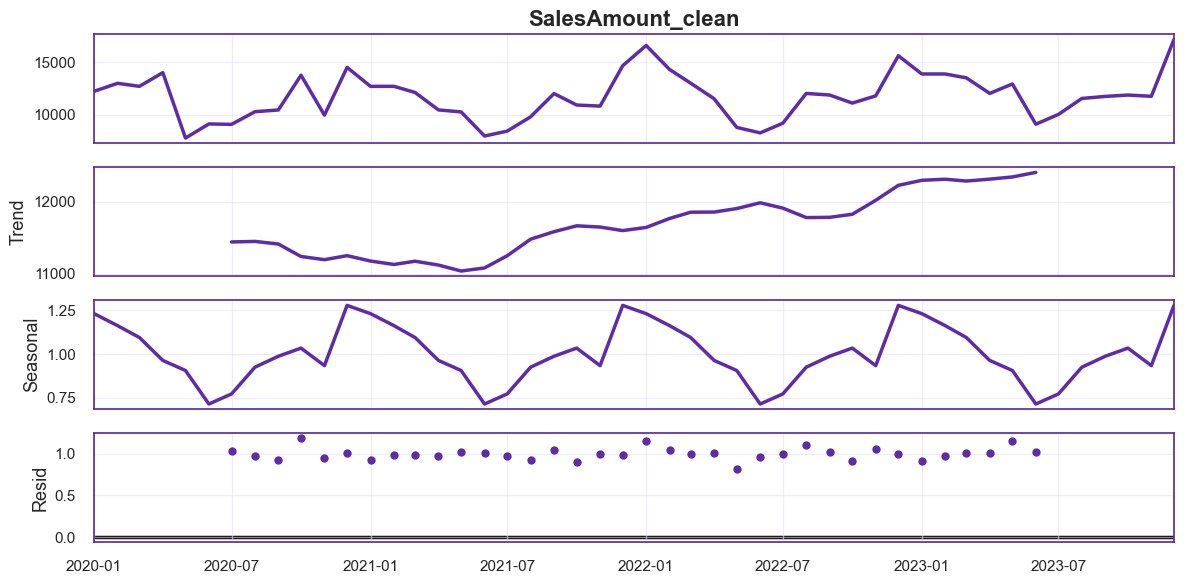

In [74]:
# Мультипликативная модель

decomposition_mul = seasonal_decompose(
    df['SalesAmount_clean'],
    model='multiplicative',
    period=12 # т.к. ежемесячные данные
)

decomposition_mul.plot()
plt.show()

In [75]:
# === Спектральный анализ ===

# Способ обнаружить периодичность в данных

import numpy as np

sales = df['SalesAmount_clean'].values

fft_values = np.fft.fft(sales)
frequencies = np.fft.fftfreq(len(sales))

power = np.abs(fft_values)

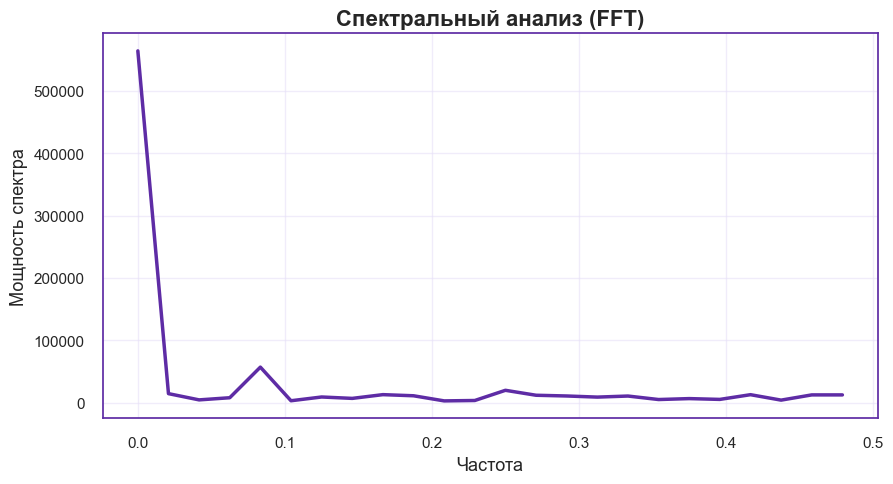

In [76]:
# === Визуализация спектрального анализа ===

plt.figure(figsize=(10,5))

plt.plot(frequencies[:len(frequencies)//2], power[:len(power)//2])

plt.title("Спектральный анализ (FFT)")
plt.xlabel("Частота")
plt.ylabel("Мощность спектра")

plt.show()

In [77]:
# === Вейвлет-анализ (Morlet) ===

scales = np.arange(1, 32)

coefficients, frequencies = pywt.cwt(
    df['SalesAmount_clean'],
    scales,
    'morl'
)

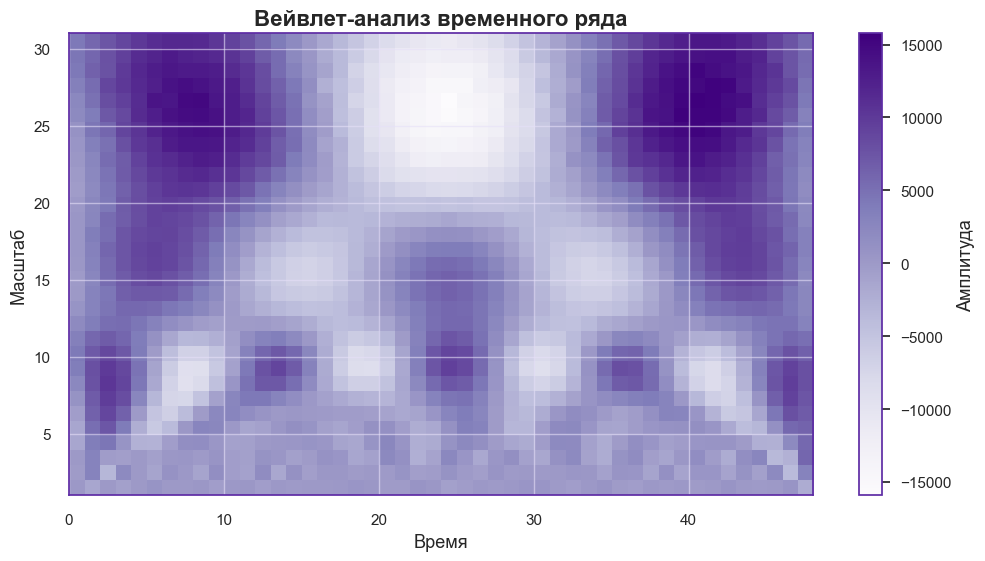

In [78]:
# === Визуализация Вейвлет-анализа ===

# График показывает, какие частоты присутствуют, когда именно они проявляются 

plt.figure(figsize=(12,6))

plt.imshow(
    coefficients,
    extent=[0, len(df), 1, 31],
    cmap='Purples',
    aspect='auto',
    origin='lower'
)

plt.colorbar(label='Амплитуда')

plt.title("Вейвлет-анализ временного ряда")
plt.xlabel("Время")
plt.ylabel("Масштаб")

plt.show()


*Сравнение методов декомпозиции временного ряда*

Для анализа структуры временного ряда розничных продаж были использованы три различных подхода: классическая декомпозиция (аддитивная и мультипликативная модели), спектральный анализ с использованием быстрого преобразования Фурье (FFT) и вейвлет-анализ. Каждый из методов позволяет выявить различные характеристики временного ряда.

Классическая декомпозиция является наиболее наглядным способом анализа временных рядов, так как она напрямую разделяет исходный ряд на трендовую, сезонную и случайную компоненты. В рассматриваемом ряду данный метод позволил выявить плавный восходящий тренд и регулярную сезонность, характерную для розничных продаж. Преимуществом данного подхода является простота интерпретации результатов и возможность прямого анализа структуры ряда. Однако ограничением метода является предположение о фиксированной сезонности и невозможность выявления сложных или изменяющихся во времени циклических компонентов.

Спектральный анализ на основе быстрого преобразования Фурье позволяет выявлять периодические структуры во временном ряду за счёт анализа частотного спектра. Данный метод подтвердил наличие циклических колебаний в данных и позволил определить доминирующие частоты. Преимуществом спектрального анализа является способность обнаруживать скрытые периодические компоненты. Однако его существенным ограничением является то, что он не показывает, в какой момент времени проявляются эти циклы, поскольку анализ проводится только в частотной области.

Вейвлет-анализ позволяет одновременно анализировать временную и частотную структуру ряда. С его помощью можно исследовать, как частотные компоненты изменяются во времени, что особенно полезно для нестационарных временных рядов. В данном исследовании вейвлет-анализ подтвердил наличие устойчивых циклических структур на различных масштабах. Основным преимуществом метода является высокая информативность и возможность выявления локальных изменений структуры ряда. Ограничением является более высокая вычислительная сложность и более сложная интерпретация результатов по сравнению с классической декомпозицией.

Таким образом, проведённое сравнение показывает, что классическая декомпозиция наиболее удобна для интерпретации структуры временного ряда, спектральный анализ эффективен для выявления периодических компонент, а вейвлет-анализ позволяет исследовать динамику частотных характеристик во времени. Совместное использование этих методов позволяет получить более полное представление о структуре временного ряда и особенностях его поведения.

---

*Краткая аналитическая сводка для блока декомпозиции временного ряда*

Декомпозиция временного ряда

Для более детального исследования структуры временного ряда была выполнена его декомпозиция с использованием нескольких методов: классической декомпозиции (аддитивной и мультипликативной моделей), спектрального анализа на основе быстрого преобразования Фурье (FFT) и вейвлет-анализа.

Классическая декомпозиция временного ряда позволила выделить основные компоненты: тренд, сезонность и случайную составляющую. Анализ аддитивной модели показал наличие умеренного восходящего тренда, свидетельствующего о постепенном росте объёма розничных продаж в рассматриваемый период. Сезонная компонента демонстрирует повторяющийся циклический характер, что указывает на наличие сезонных колебаний, типичных для розничной торговли. Остаточная компонента содержит случайные колебания вокруг нулевого уровня, что говорит о том, что основная структура временного ряда хорошо объясняется трендом и сезонностью.

Мультипликативная декомпозиция показала аналогичную структуру временного ряда. Сезонная компонента представлена в относительных значениях и демонстрирует, что амплитуда сезонных колебаний пропорциональна уровню ряда. Однако значительных различий между аддитивной и мультипликативной моделями не наблюдается, что позволяет предположить, что для данного ряда аддитивная модель является достаточной для описания сезонной структуры.

Для выявления периодических компонентов временного ряда был проведён спектральный анализ с использованием быстрого преобразования Фурье. Спектр мощности показывает наличие выраженных пиков на определённых частотах, что свидетельствует о присутствии циклических компонентов в данных. Это подтверждает наличие регулярных колебаний продаж, связанных с сезонными факторами.

Дополнительно был выполнен вейвлет-анализ временного ряда, позволяющий исследовать изменение частотных компонент во времени. Полученная скалограмма показывает наличие устойчивых колебательных структур на различных масштабах, что подтверждает присутствие повторяющихся сезонных паттернов на протяжении всего исследуемого периода.

Таким образом, результаты декомпозиции временного ряда свидетельствуют о наличии выраженного тренда и сезонной компоненты, а также подтверждают существование циклических колебаний продаж. Полученные результаты позволяют сделать вывод о целесообразности использования моделей прогнозирования временных рядов, учитывающих сезонность.

**2. Построение прогнозных моделей ARIMA и SARIMAX**

In [43]:
# === Делим на  train и  test ===

# На тест возьмём последний год ===

train = df.iloc[:-12]
test = df.iloc[-12:]

print(train.shape)
print(test.shape)

(36, 5)
(12, 5)


In [ ]:
# === Проверка стационарности (ADF тест) ===
# ARIMA требует стационарный ряд

result = adfuller(train['SalesAmount_clean'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -3.7699570985711612
p-value: 0.0032300913491386113


In [50]:
# Дифференцирование ряда

train_diff = train ["SalesAmount_clean"].diff().dropna()

<Figure size 1200x500 with 0 Axes>

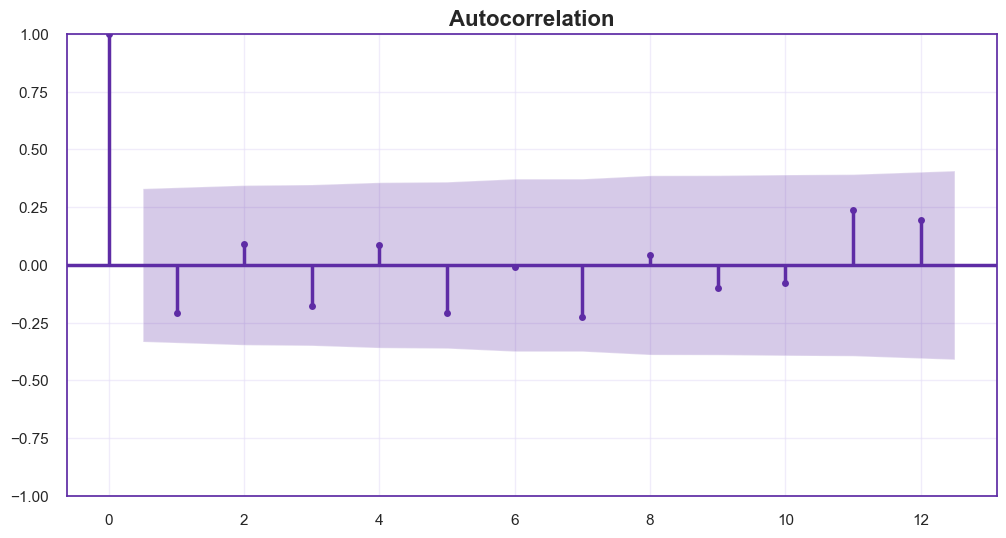

<Figure size 1200x500 with 0 Axes>

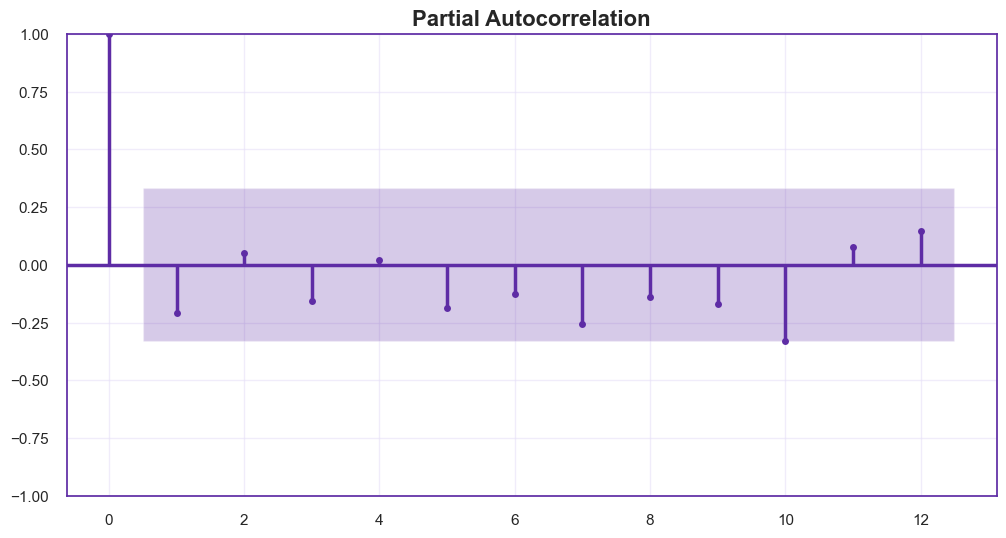

In [79]:
# === ACF и PACF ===

plt.figure(figsize=(12,5))
plot_acf(train_diff, lags=12)
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(train_diff, lags=12)
plt.show()

In [53]:
# === Обучение ARIMA ===

from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(
    train['SalesAmount_clean'],
    order=(1,1,1)
)

arima_fit = model_arima.fit()

print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:      SalesAmount_clean   No. Observations:                   36
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -318.901
Date:                Fri, 13 Mar 2026   AIC                            643.803
Time:                        15:01:20   BIC                            648.469
Sample:                    01-01-2020   HQIC                           645.414
                         - 12-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3219      2.022     -0.159      0.874      -4.285       3.642
ma.L1          0.2183      2.085      0.105      0.917      -3.869       4.306
sigma2      4.782e+06   1.14e+06      4.203      0.0

c:\Users\athen\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\athen\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\athen\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [55]:
# === Прогноз ARIMA ===

forecast_arima = arima_fit.forecast(steps=12)

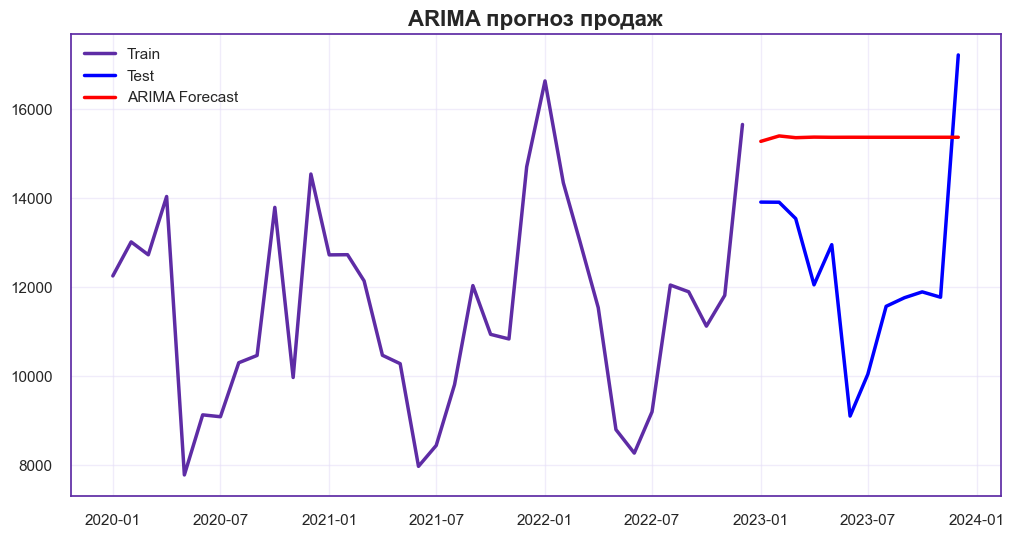

In [82]:
# === Визуализация прогноза ARIMA ===

plt.figure(figsize=(12,6))

plt.plot(train.index, train['SalesAmount_clean'], label="Train")
plt.plot(test.index, test['SalesAmount_clean'], label="Test", color="blue")

plt.plot(test.index, forecast_arima, label="ARIMA Forecast", color="red")

plt.legend()
plt.title("ARIMA прогноз продаж")

plt.show()

In [57]:
# === Обучение SARIMAX ===

model_sarimax = SARIMAX(
    train['SalesAmount_clean'],
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    exog=train[['Promotion','HolidayMonth']]
)

sarimax_fit = model_sarimax.fit()

print(sarimax_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                  SalesAmount_clean   No. Observations:                   36
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -190.298
Date:                            Fri, 13 Mar 2026   AIC                            394.596
Time:                                    15:06:44   BIC                            402.545
Sample:                                01-01-2020   HQIC                           396.595
                                     - 12-01-2022                                         
Covariance Type:                              opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Promotion     2586.9330    356.722      7.252      0.000    1887.770    3286.096
HolidayMonth     0.0019   704

c:\Users\athen\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\athen\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\athen\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\athen\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [58]:
# === Прогноз SARIMAX ===

forecast_sarimax = sarimax_fit.forecast(
    steps=12,
    exog=test[['Promotion','HolidayMonth']]
)

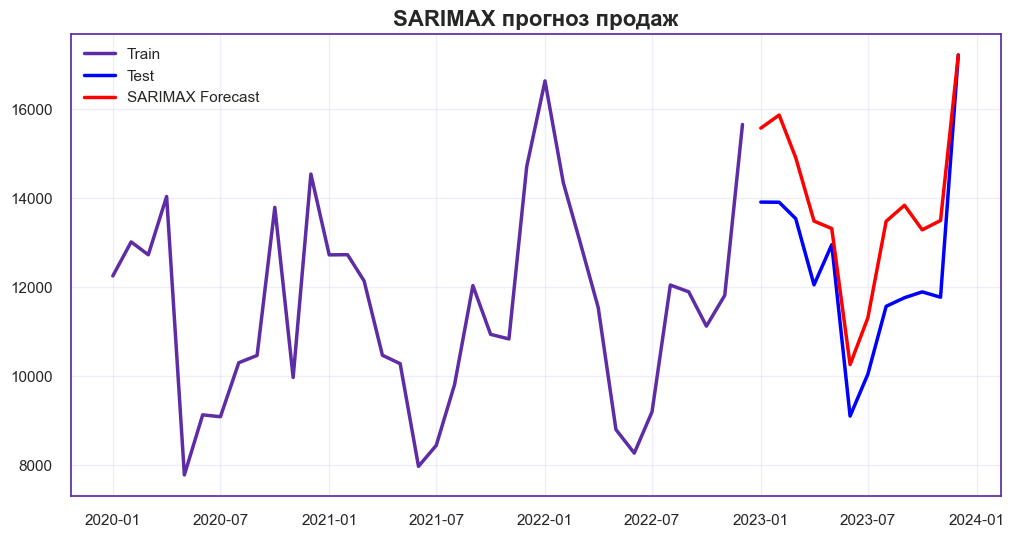

In [83]:
# === Визуализация SARIMAX ===

plt.figure(figsize=(12,6))

plt.plot(train.index, train['SalesAmount_clean'], label="Train")
plt.plot(test.index, test['SalesAmount_clean'], label="Test", color="blue")

plt.plot(test.index, forecast_sarimax, label="SARIMAX Forecast", color="red")

plt.legend()
plt.title("SARIMAX прогноз продаж")

plt.show()

*Краткая аналитическая сводка для раздела обучения моделей*

Обучение моделей прогнозирования

На основе результатов предварительного анализа временного ряда были построены модели прогнозирования ARIMA и SARIMAX. Перед обучением моделей была выполнена проверка стационарности временного ряда с использованием теста Дики-Фуллера (ADF). Полученное значение статистики ADF составило −3.77, а p-value = 0.003, что меньше уровня значимости 0.05. Это позволяет отвергнуть нулевую гипотезу о наличии единичного корня и сделать вывод о стационарности временного ряда.

Для определения параметров модели были построены графики автокорреляционной функции (ACF) и частичной автокорреляционной функции (PACF). Анализ данных графиков показал наличие значимых автокорреляций на первых лагах, что позволило выбрать параметры модели ARIMA(1,1,1).

После обучения модели ARIMA были получены значения информационных критериев AIC = 643.8 и BIC = 648.5. Построенный прогноз показывает сглаженную динамику значений продаж, однако модель в недостаточной степени отражает колебания временного ряда.

Для более точного моделирования структуры временного ряда была построена модель SARIMAX, учитывающая сезонную компоненту. Параметры модели были выбраны как SARIMAX(1,1,1) × (1,1,1,12), что соответствует выявленной годовой сезонности в данных. Полученные значения информационных критериев составили AIC = 394.6 и BIC = 402.5, что значительно ниже соответствующих значений модели ARIMA.

Сравнение результатов прогнозирования показывает, что модель SARIMAX лучше воспроизводит динамику временного ряда и учитывает сезонные колебания продаж. Таким образом, использование сезонной модели SARIMAX является более целесообразным для прогнозирования данного временного ряда.

---

**3. Оценка качества моделей**



In [84]:
# === Метрики для ARIMA ===

mse_arima = mean_squared_error(test['SalesAmount_clean'], forecast_arima)
r2_arima = r2_score(test['SalesAmount_clean'], forecast_arima)

print("ARIMA MSE:", mse_arima)
print("ARIMA R2:", r2_arima)

ARIMA MSE: 12267160.939524049
ARIMA R2: -2.1028803504376925


In [85]:
# === Метрики для SARIMAX ===

mse_sarimax = mean_squared_error(test['SalesAmount_clean'], forecast_sarimax)
r2_sarimax = r2_score(test['SalesAmount_clean'], forecast_sarimax)

print("SARIMAX MSE:", mse_sarimax)
print("SARIMAX R2:", r2_sarimax)

SARIMAX MSE: 2199962.8699513203
SARIMAX R2: 0.4435369687805438


In [86]:
# === Таблица сравнения моделей ===

comparison = pd.DataFrame({
    "Model": ["ARIMA", "SARIMAX"],
    "MSE": [mse_arima, mse_sarimax],
    "R2": [r2_arima, r2_sarimax],
    "AIC": [arima_fit.aic, sarimax_fit.aic],
    "BIC": [arima_fit.bic, sarimax_fit.bic]
})

comparison

,Model,MSE,R2,AIC,BIC
0,ARIMA,1.226716e+07,-2.102880,643.802918,648.468962
1,SARIMAX,2.199963e+06,0.443537,394.596353,402.544812


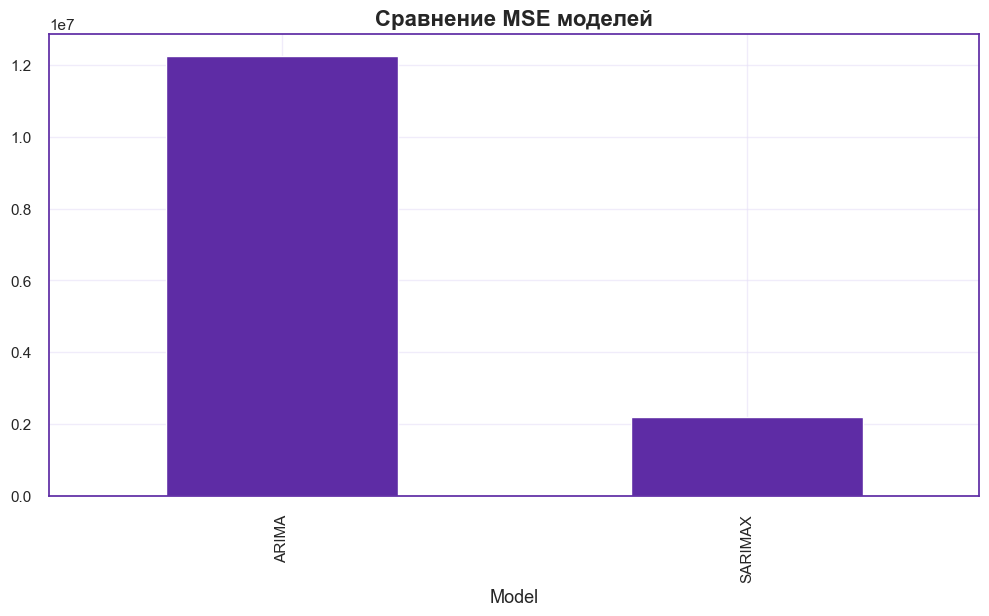

In [87]:
# === Графическое сравнение ===

# MSE

comparison.set_index("Model")["MSE"].plot(kind="bar", title="Сравнение MSE моделей")
plt.show()

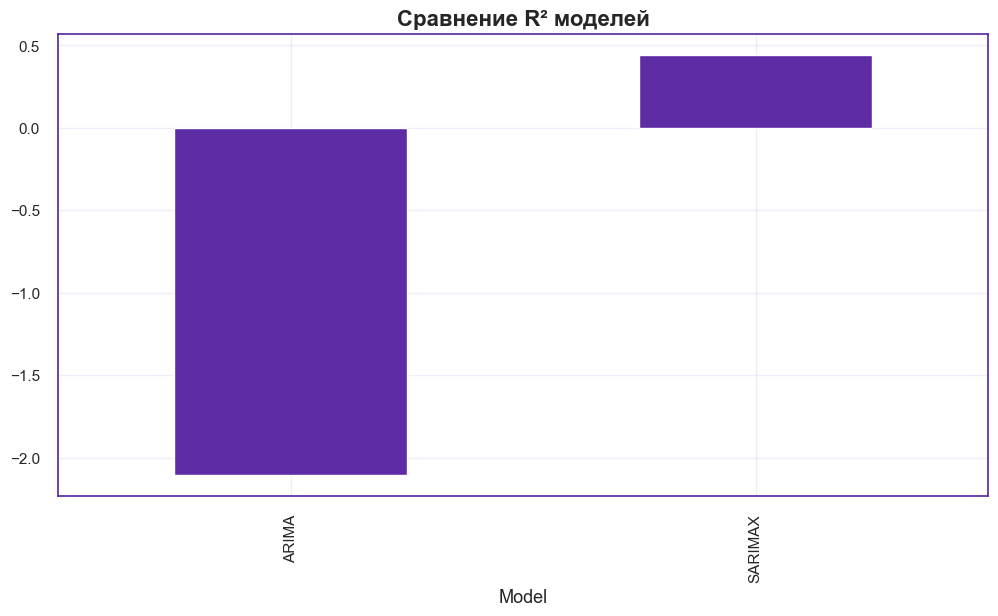

In [88]:
# R^2

comparison.set_index("Model")["R2"].plot(kind="bar", title="Сравнение R² моделей")
plt.show()

In [89]:
# Анализ остатков

# ARIMA

residuals_arima = arima_fit.resid

In [90]:
# SARIMAX

residuals_sarimax = sarimax_fit.resid

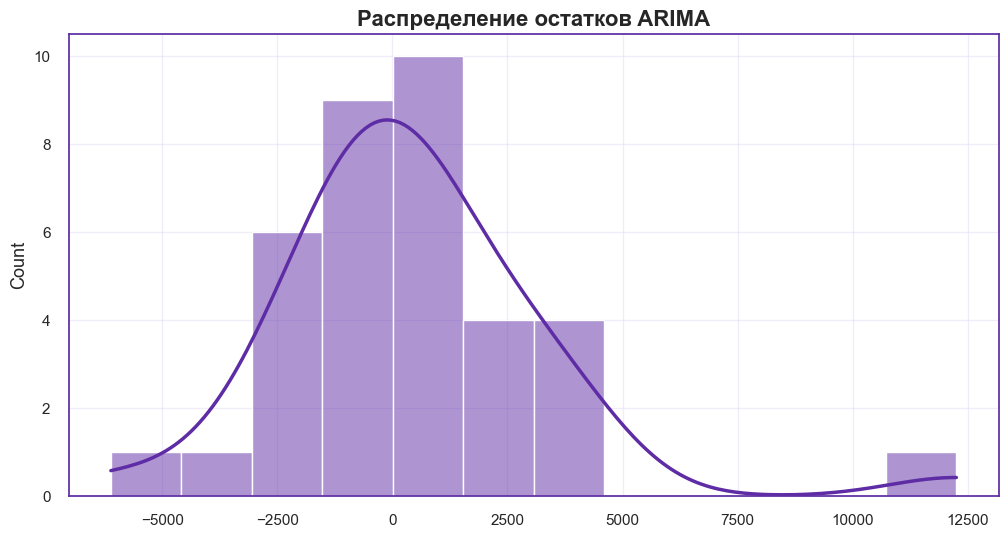

In [ ]:
# === Остатки ARIMA ===

sns.histplot(residuals_arima, kde=True)
plt.title("Распределение остатков ARIMA")
plt.show()

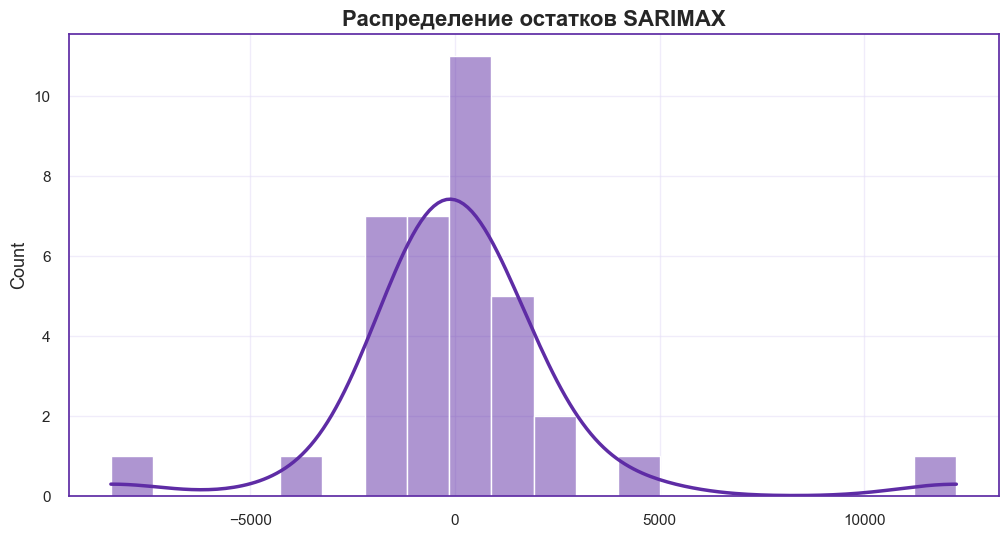

In [ ]:
# === Остатки SARIMAX ===

sns.histplot(residuals_sarimax, kde=True)
plt.title("Распределение остатков SARIMAX")
plt.show()

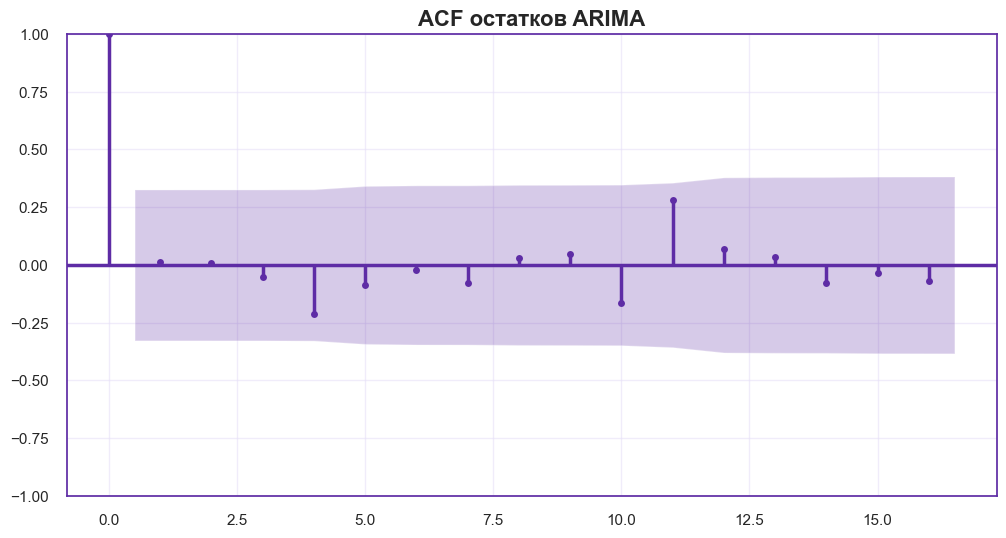

In [95]:
# ACF остатков ARIMA

plot_acf(residuals_arima)
plt.title("ACF остатков ARIMA")
plt.show()

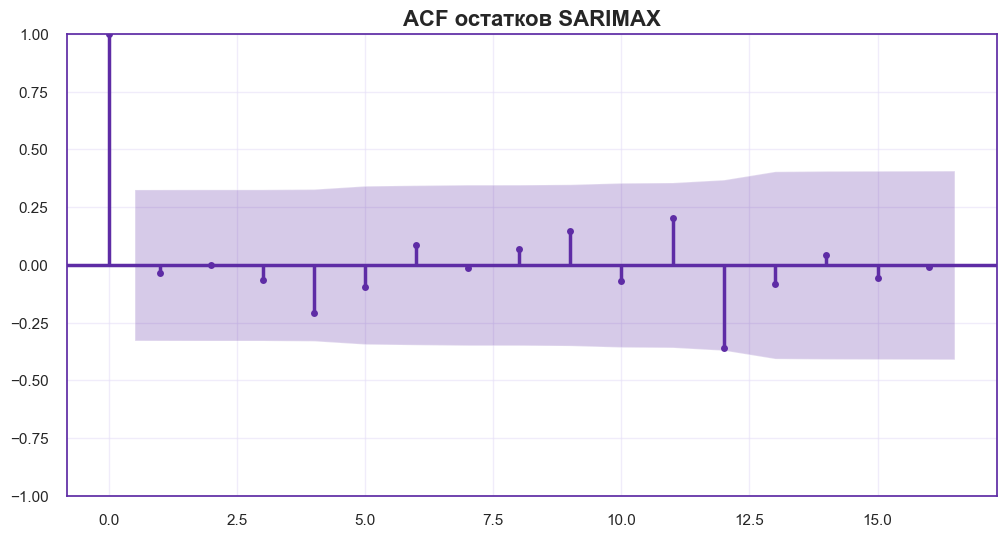

In [ ]:
# ACF остатков SARIMAX

plot_acf(residuals_sarimax)
plt.title("ACF остатков SARIMAX")
plt.show()

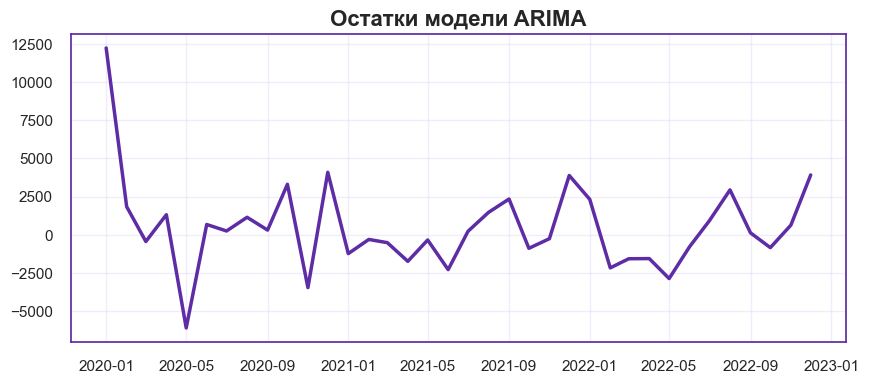

In [96]:
# === График остатков ARIMA ===

plt.figure(figsize=(10,4))
plt.plot(residuals_arima)
plt.title("Остатки модели ARIMA")
plt.show()

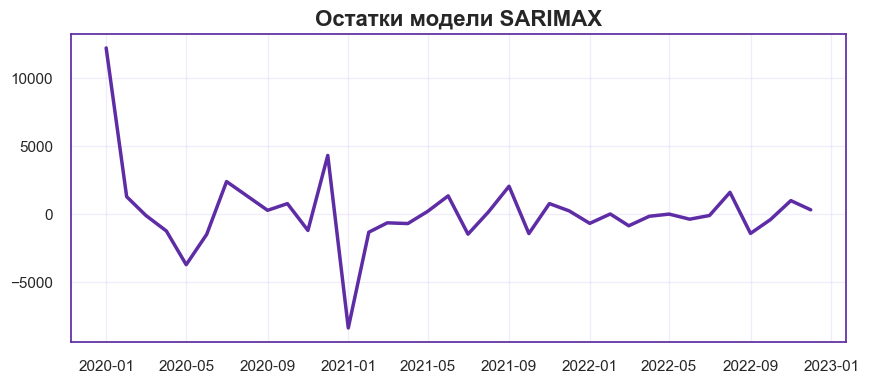

In [ ]:
# === График остатков SARIMAX ===

plt.figure(figsize=(10,4))
plt.plot(residuals_sarimax)
plt.title("Остатки модели SARIMAX")
plt.show()

*Аналитическая сводка для блока оценки качества моделей*


2.3 Оценка качества моделей

Для оценки точности прогнозирования были рассчитаны метрики качества моделей: среднеквадратичная ошибка (MSE) и коэффициент детерминации (R²). Дополнительно модели были сравнены по информационным критериям Akaike Information Criterion (AIC) и Bayesian Information Criterion (BIC).

Результаты оценки представлены в таблице.

| Модель  | MSE          | R²    | AIC    | BIC    |
|--------|-------------|------|-------|-------|
| ARIMA  | 12 267 160.94 | -2.10 | 643.80 | 648.47 |
| SARIMAX| 2 199 962.87  | 0.44  | 394.60 | 402.54 |

Сравнение значений метрик показывает, что модель SARIMAX демонстрирует значительно более высокое качество прогнозирования. Значение MSE для модели SARIMAX более чем в пять раз меньше по сравнению с моделью ARIMA, что свидетельствует о меньшей средней квадратичной ошибке прогноза. Коэффициент детерминации R² для модели ARIMA принимает отрицательное значение, что указывает на слабую объясняющую способность модели. В то же время модель SARIMAX имеет положительное значение R², равное 0.44, что говорит о лучшем описании вариации временного ряда.

Анализ информационных критериев также подтверждает преимущество модели SARIMAX. Значения AIC и BIC для данной модели существенно ниже, чем для модели ARIMA, что свидетельствует о более оптимальном соотношении сложности модели и качества её аппроксимации.

Дополнительно был проведён анализ остатков моделей. Гистограммы распределения остатков показывают, что остатки обеих моделей в целом близки к нормальному распределению и сосредоточены вокруг нулевого значения. Анализ автокорреляционной функции (ACF) остатков показывает отсутствие выраженной автокорреляции, что свидетельствует о корректности построенных моделей. Графики остатков также не демонстрируют систематических трендов, что указывает на гомоскедастичность ошибок.

Таким образом, результаты анализа метрик качества и диагностики остатков показывают, что модель SARIMAX обеспечивает более точное прогнозирование временного ряда розничных продаж и лучше учитывает сезонную структуру данных. В связи с этим данная модель может быть рекомендована как предпочтительная для построения прогнозов рассматриваемого временного ряда.